# Online Shopper Conversion: Modelling and Evaluation

This notebook builds and evaluates purchase-intent models using the cleaned session data. It is standalone, but the companion EDA notebook explains the data-quality choices and behavioural patterns in more detail.

The goal is not merely to maximise accuracy. The analysis separates early-session assistance from late-session prioritisation, selects thresholds on validation data, tests ranking and calibration, and checks whether performance depends too heavily on `PageValues`.

## Setup and validation design

The data are split into training, validation and test sets using stratification. The validation set is used for model and threshold decisions; the test set remains untouched until final evaluation.

In [4]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

RANDOM_STATE = 7705
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

SAVE_FIGURES = True
FIGURE_DIR = Path("outputs/figures")
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def finish_figure(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()

In [5]:
candidate_paths = [
    Path("online_shoppers_intention.csv"),
    Path("data/online_shoppers_intention.csv"),
]

csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        "Could not find online_shoppers_intention.csv. "
        "Download the official UCI file and place it beside this notebook or inside a data/ folder."
    )

df_raw = pd.read_csv(csv_path)
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
display(df_raw.head())

df = df_raw.drop_duplicates().reset_index(drop=True).copy()
print(f"Rows retained after exact-duplicate removal: {len(df):,}")

Shape: 12,330 rows × 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0000,0,0.0000,2,64.0000,0.0000,0.1000,0.0000,0.0000,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0000,0,0.0000,1,0.0000,0.2000,0.2000,0.0000,0.0000,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0000,0,0.0000,2,2.6667,0.0500,0.1400,0.0000,0.0000,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0000,0,0.0000,10,627.5000,0.0200,0.0500,0.0000,0.0000,Feb,3,3,1,4,Returning_Visitor,True,False


Rows retained after exact-duplicate removal: 12,205


**Decision framework**

| Decision element | Working assumption | Why it matters |
|---|---|---|
| Who acts? | E-commerce lifecycle or onsite-experience team | Defines ownership of the score |
| When is scoring performed? | During or immediately after a session | Determines which features are genuinely available |
| What action follows? | Help prompt, reassurance, guidance or prioritised follow-up | Changes the cost of false positives and false negatives |
| What is success? | Incremental conversion or margin | Prediction alone does not prove business impact |

Two uses are treated separately:

- _Early-session assistance:_ should avoid features known only late in the journey. Low-cost, helpful actions are more defensible than indiscriminate discounts.
- _Late-session prioritisation:_ may include richer features such as `PageValues`, provided their availability is verified at the scoring time.

Each row is a session, not a confirmed unique customer. There are no timestamps, customer IDs, order values or treatment logs, so the workflow estimates predictive performance rather than causal uplift or profit.

**Feature timing and preprocessing**

Visit context is usually available early; engagement counts and durations accumulate as browsing continues; `PageValues` is especially outcome-adjacent. The full model is therefore treated as a late-session benchmark, while the model without `PageValues` is the more credible early-intervention candidate.

Numerical variables use median imputation and standardisation. Categorical variables use most-frequent imputation and one-hot encoding with unknown categories ignored.

In [8]:
target = "Revenue"
X = df.drop(columns=target)
y = df[target].astype(int)

categorical_features = [
    "Month", "OperatingSystems", "Browser",
    "Region", "TrafficType", "VisitorType", "Weekend"
]
numeric_features = [column for column in X.columns if column not in categorical_features]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_validation), len(X_test)],
    "purchase_rate": [y_train.mean(), y_validation.mean(), y_test.mean()]
}, index=["Train", "Validation", "Test"])

display(split_summary)

,rows,purchase_rate
Train,7323,0.1564
Validation,2441,0.1561
Test,2441,0.1565


In [9]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

## Model comparison and final evaluation

Logistic regression provides a transparent linear benchmark. Random forest and gradient boosting capture nonlinear patterns and interactions. Since purchasers are the minority, PR-AUC is the primary ranking metric; accuracy is retained only as supporting context.

In [11]:
def metric_row(model_name, y_true, probability, threshold=0.50):
    prediction = (probability >= threshold).astype(int)
    return {
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_true, probability),
        "PR-AUC": average_precision_score(y_true, probability),
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0)
    }

majority_probability = np.repeat(y_train.mean(), len(y_validation))
majority_prediction = np.zeros(len(y_validation), dtype=int)

baseline_results = pd.DataFrame([{
    "Model": "Majority-class baseline",
    "ROC-AUC": 0.50,
    "PR-AUC": y_validation.mean(),
    "Accuracy": accuracy_score(y_validation, majority_prediction),
    "Precision": 0.0,
    "Recall": 0.0,
    "F1": 0.0
}])

display(baseline_results)

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
0,Majority-class baseline,0.5000,0.1561,0.8439,0.0000,0.0000,0.0000


In [12]:
model_definitions = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=350,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        random_state=RANDOM_STATE
    )
}

fitted_models = {}
validation_probabilities = {}
validation_rows = []

for model_name, estimator in model_definitions.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", estimator)
    ])
    pipeline.fit(X_train, y_train)
    probability = pipeline.predict_proba(X_validation)[:, 1]

    fitted_models[model_name] = pipeline
    validation_probabilities[model_name] = probability
    validation_rows.append(metric_row(model_name, y_validation, probability))

validation_results = (
    pd.concat([baseline_results, pd.DataFrame(validation_rows)], ignore_index=True)
    .sort_values("PR-AUC", ascending=False)
)
display(validation_results)

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
3,Gradient Boosting,0.9233,0.7349,0.9005,0.7066,0.6194,0.6601
2,Random Forest,0.9269,0.7341,0.8935,0.6353,0.7454,0.6860
1,Logistic Regression,0.8991,0.6511,0.8480,0.5088,0.7559,0.6082
0,Majority-class baseline,0.5000,0.1561,0.8439,0.0000,0.0000,0.0000


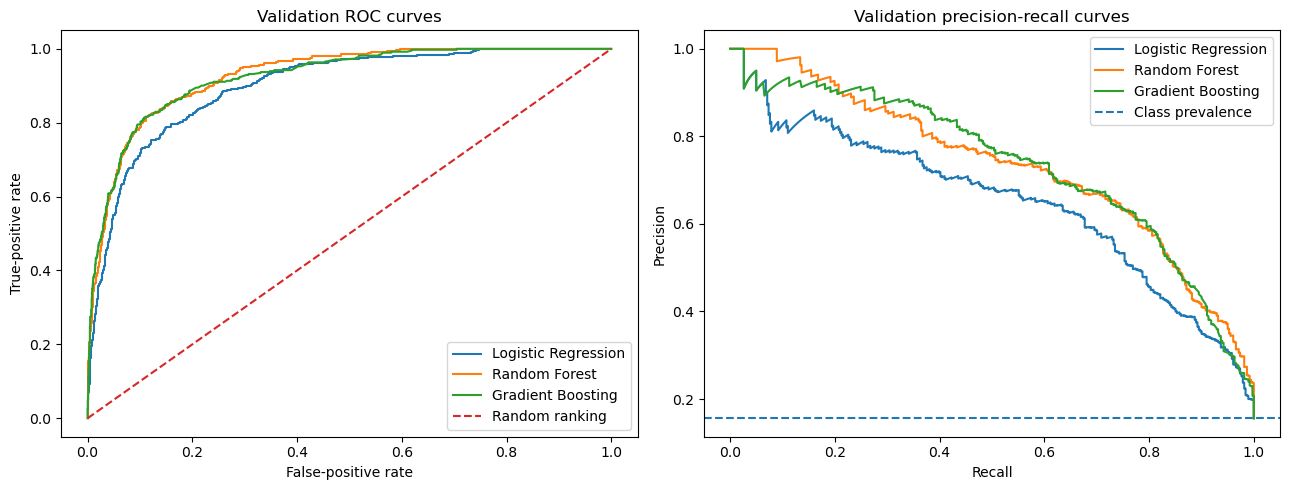

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model_name, probability in validation_probabilities.items():
    fpr, tpr, _ = roc_curve(y_validation, probability)
    precision, recall, _ = precision_recall_curve(y_validation, probability)
    axes[0].plot(fpr, tpr, label=model_name)
    axes[1].plot(recall, precision, label=model_name)

axes[0].plot([0, 1], [0, 1], linestyle="--", label="Random ranking")
axes[0].set_title("Validation ROC curves")
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].legend()

axes[1].axhline(y_validation.mean(), linestyle="--", label="Class prevalence")
axes[1].set_title("Validation precision-recall curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

finish_figure(fig, "05_validation_roc_and_pr_curves.png")

**Cross-validation stability check**

The held-out validation result can vary depending on one split. Five-fold stratified cross-validation on the training data provides a stability check. This is not used to touch the final test set.

,Model,CV ROC-AUC mean,CV ROC-AUC std,CV PR-AUC mean,CV PR-AUC std,CV F1 mean
2,Gradient Boosting,0.9292,0.0078,0.7456,0.0196,0.6667
1,Random Forest,0.9272,0.0072,0.7366,0.0157,0.6810
0,Logistic Regression,0.8993,0.0084,0.6429,0.0064,0.6059


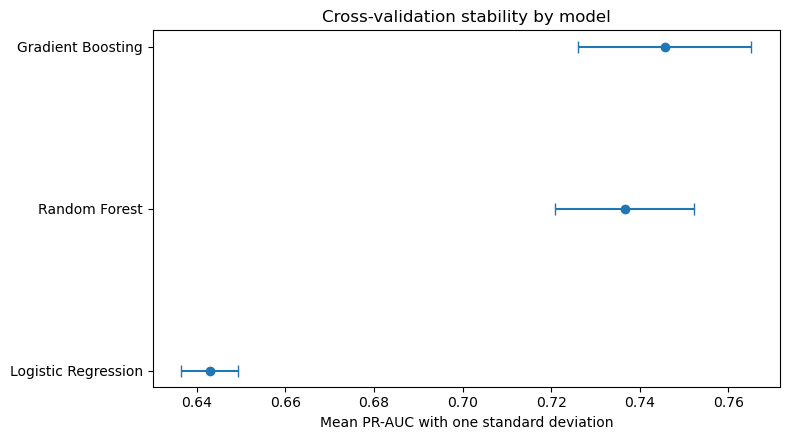

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for model_name, estimator in model_definitions.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", estimator)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "average_precision": "average_precision",
            "f1": "f1"
        },
        n_jobs=-1
    )

    cv_rows.append({
        "Model": model_name,
        "CV ROC-AUC mean": scores["test_roc_auc"].mean(),
        "CV ROC-AUC std": scores["test_roc_auc"].std(),
        "CV PR-AUC mean": scores["test_average_precision"].mean(),
        "CV PR-AUC std": scores["test_average_precision"].std(),
        "CV F1 mean": scores["test_f1"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV PR-AUC mean", ascending=False)
display(cv_results)

plot_cv = cv_results.sort_values("CV PR-AUC mean")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    plot_cv["CV PR-AUC mean"],
    plot_cv["Model"],
    xerr=plot_cv["CV PR-AUC std"],
    fmt="o",
    capsize=4
)
ax.set_title("Cross-validation stability by model")
ax.set_xlabel("Mean PR-AUC with one standard deviation")
finish_figure(fig, "06_cross_validation_stability.png")

**Model-selection rule**

The winning model is selected using **validation PR-AUC**, because purchasers are the minority and the business needs useful positive-session ranking. However, the final choice is not based on performance alone.

A model is considered deployable only when:

- its features are available at the intended scoring time;
- its performance is stable across validation folds and key segments;
- its probabilities are sufficiently calibrated for the intended decision;
- its operating threshold reflects action cost and capacity;
- its impact is confirmed experimentally.

This prevents the familiar portfolio trap of declaring victory because one metric is high.

**Operating policy and final evaluation**

A predicted probability must be converted into an action using a threshold.

The default threshold of 0.50 is not automatically optimal. For demonstration, the notebook selects the threshold that maximises validation F1. In a real campaign, threshold selection should instead reflect:

- contact or incentive cost;
- expected margin from a conversion;
- available marketing capacity;
- cost of missing a likely purchaser;
- customer-experience risk from unnecessary targeting.

The best model is selected primarily by validation **PR-AUC**, then its threshold is selected using validation data only.

In [18]:
best_model_name = (
    pd.DataFrame(validation_rows)
    .sort_values(["PR-AUC", "ROC-AUC"], ascending=False)
    .iloc[0]["Model"]
)

best_validation_probability = validation_probabilities[best_model_name]

precision_values, recall_values, thresholds = precision_recall_curve(
    y_validation, best_validation_probability
)

threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision_values[:-1],
    "recall": recall_values[:-1]
})
threshold_table["f1"] = (
    2 * threshold_table["precision"] * threshold_table["recall"] /
    (threshold_table["precision"] + threshold_table["recall"])
).fillna(0)

best_threshold_row = threshold_table.loc[threshold_table["f1"].idxmax()]
selected_threshold = float(best_threshold_row["threshold"])

print(f"Selected model: {best_model_name}")
print(f"Validation-selected threshold: {selected_threshold:.3f}")
display(best_threshold_row.to_frame("value"))

Selected model: Gradient Boosting
Validation-selected threshold: 0.396


,value
threshold,0.3958
precision,0.6741
recall,0.7165
f1,0.6947


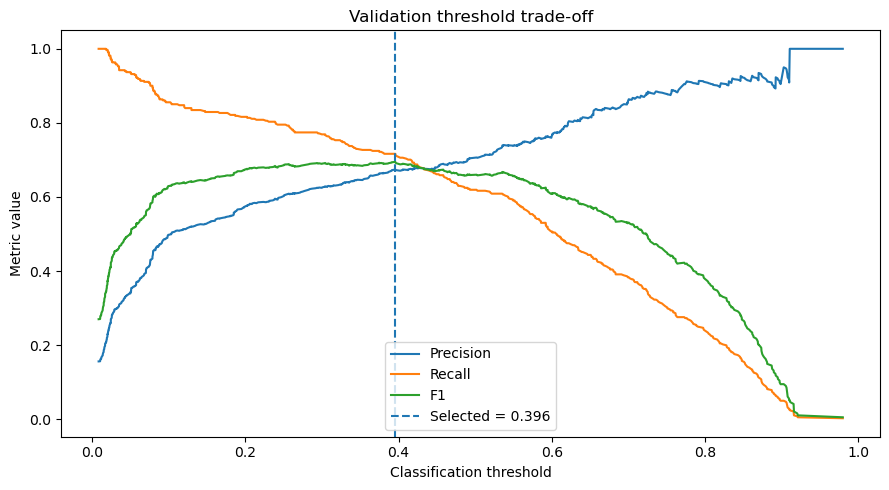

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
ax.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
ax.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")
ax.axvline(selected_threshold, linestyle="--", label=f"Selected = {selected_threshold:.3f}")
ax.set_title("Validation threshold trade-off")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Metric value")
ax.legend()
finish_figure(fig, "07_threshold_tradeoff.png")

**Refit and test**

After the model family and threshold have been selected, the winning model is refitted on the combined training and validation data. The untouched test set is then evaluated once.

In [21]:
X_train_final = pd.concat([X_train, X_validation], axis=0)
y_train_final = pd.concat([y_train, y_validation], axis=0)

final_model = clone(fitted_models[best_model_name])
final_model.fit(X_train_final, y_train_final)

test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= selected_threshold).astype(int)

test_results = pd.DataFrame([
    metric_row(
        f"{best_model_name} at selected threshold",
        y_test,
        test_probability,
        selected_threshold
    ),
    metric_row(
        f"{best_model_name} at 0.50 threshold",
        y_test,
        test_probability,
        0.50
    )
])

display(test_results)

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
0,Gradient Boosting at selected threshold,0.9276,0.7393,0.8976,0.6833,0.6440,0.6631
1,Gradient Boosting at 0.50 threshold,0.9276,0.7393,0.8976,0.7276,0.5524,0.6280


Classification report at selected threshold
              precision    recall  f1-score   support

 No purchase      0.935     0.945     0.940      2059
    Purchase      0.683     0.644     0.663       382

    accuracy                          0.898      2441
   macro avg      0.809     0.794     0.801      2441
weighted avg      0.895     0.898     0.896      2441



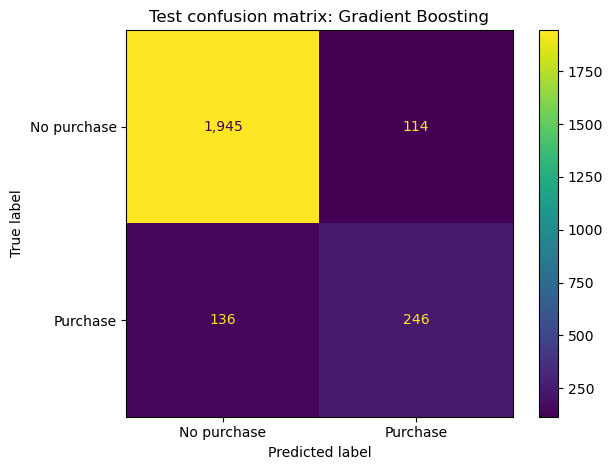

In [22]:
print("Classification report at selected threshold")
print(classification_report(
    y_test,
    test_prediction,
    target_names=["No purchase", "Purchase"],
    digits=3
))

display_cm = ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=["No purchase", "Purchase"],
    values_format=",d"
)
fig = display_cm.figure_
display_cm.ax_.set_title(f"Test confusion matrix: {best_model_name}")
finish_figure(fig, "08_test_confusion_matrix.png")

In [23]:
scored_test = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "probability": test_probability
})

scored_test["risk_decile"] = pd.qcut(
    scored_test["probability"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

lift_table = (
    scored_test.groupby("risk_decile")
    .agg(
        sessions=("actual", "size"),
        purchases=("actual", "sum"),
        conversion_rate=("actual", "mean"),
        average_score=("probability", "mean")
    )
    .sort_index(ascending=False)
)

lift_table["lift_vs_average"] = lift_table["conversion_rate"] / y_test.mean()
display(lift_table)

,sessions,purchases,conversion_rate,average_score,lift_vs_average
risk_decile,,,,,
10,244,187,0.7664,0.7418,4.8973
9,244,105,0.4303,0.3950,2.7498
8,224,45,0.2009,0.1426,1.2837
7,247,22,0.0891,0.0727,0.5692
6,261,13,0.0498,0.0415,0.3183
5,242,9,0.0372,0.0275,0.2376
4,246,1,0.0041,0.0222,0.0260
3,218,0,0.0000,0.0185,0.0000
2,255,0,0.0000,0.0150,0.0000


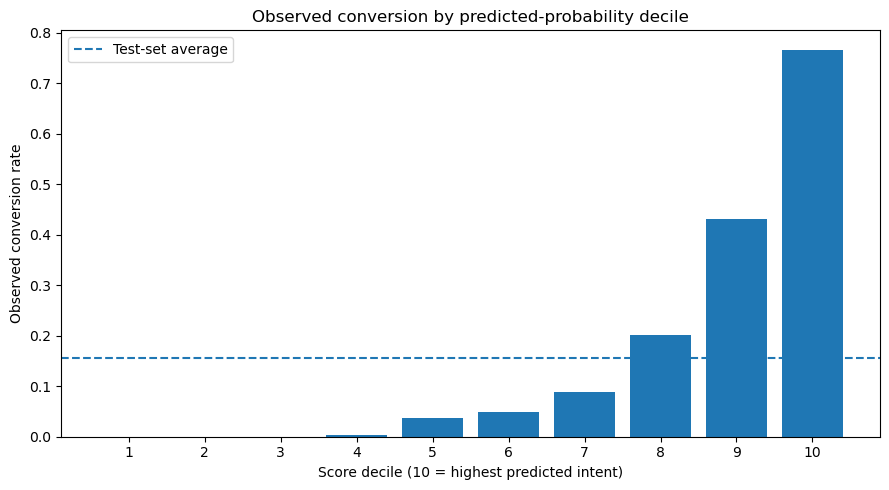

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
ordered_lift = lift_table.sort_index()
ax.bar(ordered_lift.index.astype(str), ordered_lift["conversion_rate"])
ax.axhline(y_test.mean(), linestyle="--", label="Test-set average")
ax.set_title("Observed conversion by predicted-probability decile")
ax.set_xlabel("Score decile (10 = highest predicted intent)")
ax.set_ylabel("Observed conversion rate")
ax.legend()
finish_figure(fig, "09_conversion_by_score_decile.png")

## Commercial use and reliability

The next checks translate model scores into capacity decisions, assess probability calibration, inspect feature importance and test reliability across segments. Ranking likely purchasers is useful, but it should not be confused with identifying customers whose behaviour can be changed.

**Commercial usefulness: ranking, capacity and calibration**

_Ranking is often more useful than a hard yes/no label_

The table answers the question: **if the business can only act on a limited share of sessions, where should it focus?**

A strong top-decile lift means a small operations or campaign team can concentrate effort rather than contacting everyone. Yet targeting the highest-propensity shoppers is not automatically the best intervention strategy. Some are likely to purchase anyway.

The safest interpretation is:

- use the score to _prioritise analysis or low-cost service_;
- avoid assuming that the highest score equals the highest incremental uplift;
- test whether medium-high intent sessions respond more than already-certain purchasers.

In [27]:
# Cumulative gains: what share of all purchasers is captured when capacity is limited?
ranked = scored_test.sort_values("probability", ascending=False).reset_index(drop=True)
ranked["population_share"] = (np.arange(len(ranked)) + 1) / len(ranked)
ranked["cumulative_purchase_share"] = ranked["actual"].cumsum() / ranked["actual"].sum()

capacity_levels = [0.05, 0.10, 0.20, 0.30, 0.50]
capacity_rows = []
for capacity in capacity_levels:
    n_target = max(1, int(np.ceil(capacity * len(ranked))))
    selected = ranked.head(n_target)
    capacity_rows.append({
        "Targeted share of sessions": capacity,
        "Sessions targeted": n_target,
        "Purchasers captured": int(selected["actual"].sum()),
        "Share of all purchasers captured": selected["actual"].sum() / ranked["actual"].sum(),
        "Conversion among targeted": selected["actual"].mean(),
        "Lift vs average": selected["actual"].mean() / ranked["actual"].mean()
    })

capacity_table = pd.DataFrame(capacity_rows)
display(capacity_table.style.format({
    "Targeted share of sessions": "{:.0%}",
    "Share of all purchasers captured": "{:.1%}",
    "Conversion among targeted": "{:.1%}",
    "Lift vs average": "{:.2f}x"
}))

,Targeted share of sessions,Sessions targeted,Purchasers captured,Share of all purchasers captured,Conversion among targeted,Lift vs average
0,5%,123,111,29.1%,90.2%,5.77x
1,10%,245,187,49.0%,76.3%,4.88x
2,20%,489,292,76.4%,59.7%,3.82x
3,30%,733,340,89.0%,46.4%,2.96x
4,50%,1221,372,97.4%,30.5%,1.95x


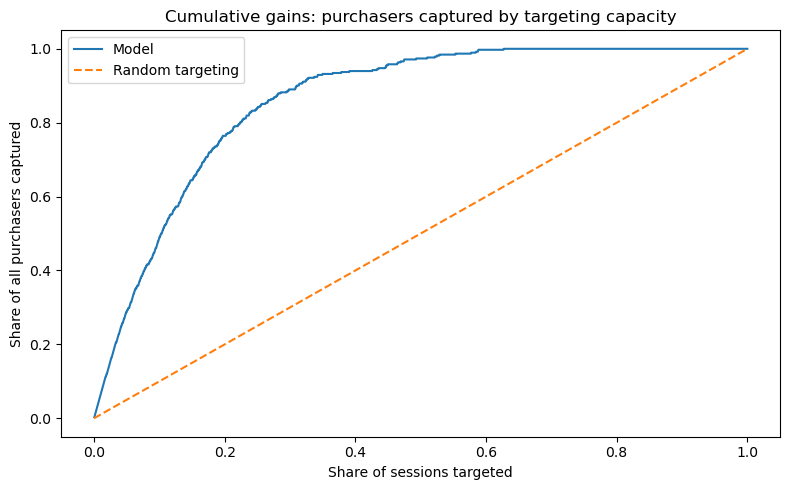

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ranked["population_share"], ranked["cumulative_purchase_share"], label="Model")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random targeting")
ax.set_title("Cumulative gains: purchasers captured by targeting capacity")
ax.set_xlabel("Share of sessions targeted")
ax.set_ylabel("Share of all purchasers captured")
ax.legend()
finish_figure(fig, "10_cumulative_gains.png")

**Probability calibration**: A ranking model may order sessions correctly while its probability values remain inaccurate. Calibration matters when predicted probabilities feed budget, expected-value or staffing decisions.

The next check compares predicted probabilities with observed conversion and reports the **Brier score**. Lower Brier scores indicate more accurate probability estimates.

Test Brier score: 0.0726


,Mean predicted probability,Observed conversion rate,Calibration gap
0,1.1%,0.0%,-1.1%
1,1.5%,0.0%,-1.5%
2,1.8%,0.0%,-1.8%
3,2.2%,0.4%,-1.8%
4,2.7%,3.7%,1.0%
5,4.2%,5.0%,0.8%
6,7.3%,8.9%,1.6%
7,14.3%,20.1%,5.8%
8,39.5%,43.0%,3.5%
9,74.2%,76.6%,2.5%


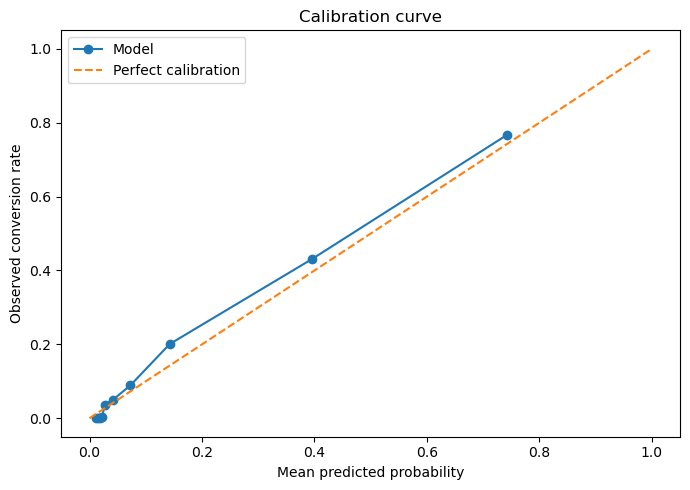

In [30]:
brier = brier_score_loss(y_test, test_probability)
fraction_positive, mean_predicted = calibration_curve(
    y_test, test_probability, n_bins=10, strategy="quantile"
)

calibration_table = pd.DataFrame({
    "Mean predicted probability": mean_predicted,
    "Observed conversion rate": fraction_positive,
    "Calibration gap": fraction_positive - mean_predicted
})
print(f"Test Brier score: {brier:.4f}")
display(calibration_table.style.format("{:.1%}"))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(mean_predicted, fraction_positive, marker="o", label="Model")
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.set_title("Calibration curve")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed conversion rate")
ax.legend()
finish_figure(fig, "11_calibration_curve.png")

**Illustrative value-based thresholding**
The dataset contains no order value, intervention cost or incremental uplift. Therefore, profit cannot be estimated honestly without assumptions.

The scenario analysis below is deliberately labelled _illustrative_. It asks how threshold choice changes when the business supplies:

- contribution margin per incremental conversion;
- intervention cost per contacted session;
- expected incremental uplift among true opportunities;
- cost of an unnecessary intervention.

This is more decision-relevant than maximising F1, but the assumptions must be replaced with real business inputs before deployment.

Illustrative assumptions only. Replace with experimental and finance inputs.


,Selected operating point
threshold,0.530
sessions_targeted,266.000
target_rate,0.109
precision,0.752
recall,0.524
expected_incremental_conversions,10.000
illustrative_expected_value,214.800


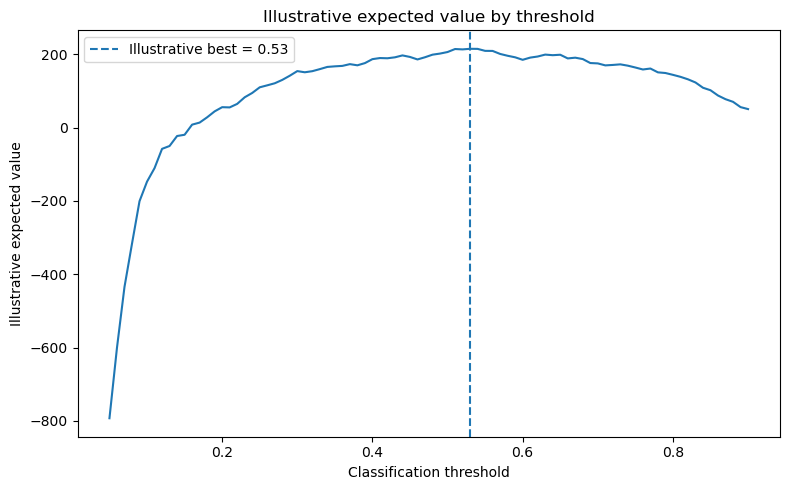

In [32]:
def threshold_value_table(
    y_true,
    probability,
    incremental_margin=40.0,
    intervention_cost=0.20,
    expected_uplift=0.05,
    unnecessary_offer_cost=2.00,
    thresholds=np.linspace(0.05, 0.90, 86)
):
    rows = []
    y_arr = np.asarray(y_true).astype(int)
    for threshold in thresholds:
        targeted = probability >= threshold
        tp = int(((targeted == 1) & (y_arr == 1)).sum())
        fp = int(((targeted == 1) & (y_arr == 0)).sum())
        targeted_n = int(targeted.sum())
        expected_incremental_conversions = tp * expected_uplift
        expected_value = (
            expected_incremental_conversions * incremental_margin
            - targeted_n * intervention_cost
            - fp * unnecessary_offer_cost
        )
        rows.append({
            "threshold": threshold,
            "sessions_targeted": targeted_n,
            "target_rate": targeted_n / len(y_arr),
            "precision": precision_score(y_arr, targeted, zero_division=0),
            "recall": recall_score(y_arr, targeted, zero_division=0),
            "expected_incremental_conversions": expected_incremental_conversions,
            "illustrative_expected_value": expected_value
        })
    return pd.DataFrame(rows)

value_table = threshold_value_table(y_test, test_probability)
best_value_row = value_table.loc[value_table["illustrative_expected_value"].idxmax()]
print("Illustrative assumptions only. Replace with experimental and finance inputs.")
display(best_value_row.to_frame("Selected operating point").style.format({
    "Selected operating point": "{:.3f}"
}))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(value_table["threshold"], value_table["illustrative_expected_value"])
ax.axvline(
    best_value_row["threshold"],
    linestyle="--",
    label=f"Illustrative best = {best_value_row['threshold']:.2f}"
)
ax.set_title("Illustrative expected value by threshold")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Illustrative expected value")
ax.legend()
finish_figure(fig, "12_illustrative_value_by_threshold.png")

**Model interpretation and segment reliability**

Permutation importance measures how much predictive performance deteriorates when one original feature is shuffled. It is:
- model-agnostic;
- calculated on unseen test data;
- expressed at the original feature level;
- easier to compare than dozens of one-hot encoded columns.

Importance is not causality. A feature can be predictive because it is correlated with another feature or because it is measured late in the session.

In [34]:
importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_table = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

display(importance_table)

,feature,importance_mean,importance_std
8,PageValues,0.5390,0.0093
10,Month,0.0457,0.0053
6,BounceRates,0.0278,0.0073
0,Administrative,0.0135,0.0018
15,VisitorType,0.0109,0.0025
5,ProductRelated_Duration,0.0094,0.0040
7,ExitRates,0.0073,0.0026
4,ProductRelated,0.0064,0.0020
1,Administrative_Duration,0.0029,0.0009
14,TrafficType,0.0015,0.0009


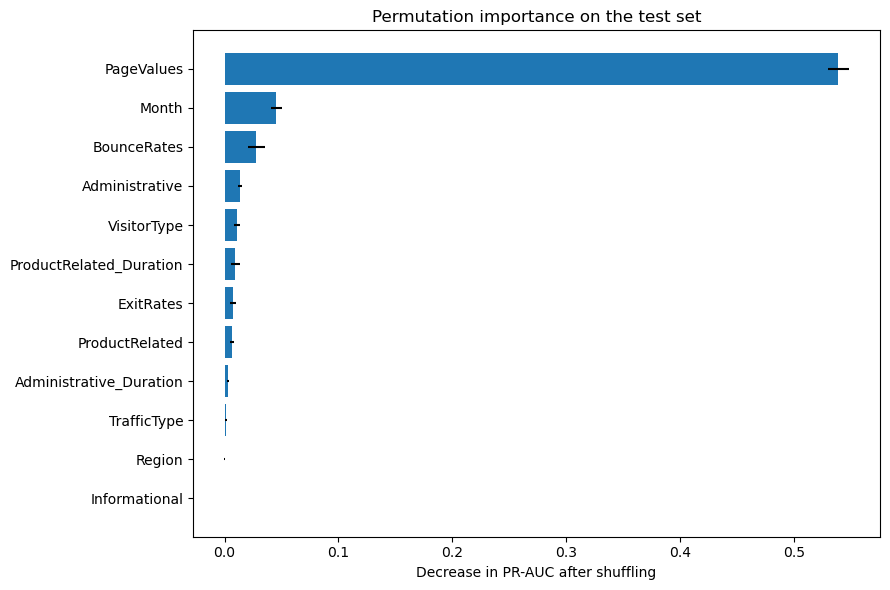

In [35]:
top_importance = importance_table.head(12).sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"]
)
ax.set_title("Permutation importance on the test set")
ax.set_xlabel("Decrease in PR-AUC after shuffling")
finish_figure(fig, "13_permutation_importance.png")

**Segment reliability**
A model can perform well overall while failing for an important traffic or visitor segment. The following diagnostics compare volume, prevalence, ranking quality and threshold performance across commercially relevant groups.

Small groups should be interpreted cautiously. Segment results are monitoring signals, not proof that the model treats individuals fairly or causally.

In [37]:
from sklearn.metrics import average_precision_score, roc_auc_score

def segment_performance(X_segment, y_true, probability, prediction, columns, min_n=80):
    frames = []
    base = X_segment.reset_index(drop=True).copy()
    base["actual"] = np.asarray(y_true).astype(int)
    base["probability"] = np.asarray(probability)
    base["prediction"] = np.asarray(prediction).astype(int)

    for column in columns:
        for value, group in base.groupby(column, dropna=False):
            if len(group) < min_n or group["actual"].nunique() < 2:
                continue
            frames.append({
                "segment": column,
                "value": value,
                "sessions": len(group),
                "conversion_rate": group["actual"].mean(),
                "PR_AUC": average_precision_score(group["actual"], group["probability"]),
                "ROC_AUC": roc_auc_score(group["actual"], group["probability"]),
                "precision": precision_score(group["actual"], group["prediction"], zero_division=0),
                "recall": recall_score(group["actual"], group["prediction"], zero_division=0)
            })
    return pd.DataFrame(frames)

segment_table = segment_performance(
    X_test,
    y_test,
    test_probability,
    test_prediction,
    columns=["VisitorType", "Weekend", "Month"],
    min_n=80
)
display(segment_table.sort_values(["segment", "sessions"], ascending=[True, False]).style.format({
    "conversion_rate": "{:.1%}",
    "PR_AUC": "{:.3f}",
    "ROC_AUC": "{:.3f}",
    "precision": "{:.1%}",
    "recall": "{:.1%}"
}))

,segment,value,sessions,conversion_rate,PR_AUC,ROC_AUC,precision,recall
8,Month,May,677,9.6%,0.843,0.981,70.4%,87.7%
9,Month,Nov,592,26.9%,0.742,0.858,70.9%,62.9%
7,Month,Mar,387,11.9%,0.783,0.974,69.2%,58.7%
5,Month,Dec,327,9.5%,0.590,0.896,48.6%,54.8%
10,Month,Oct,115,21.7%,0.792,0.896,76.0%,76.0%
6,Month,Jul,94,14.9%,0.658,0.870,66.7%,42.9%
4,Month,Aug,92,15.2%,0.743,0.917,80.0%,57.1%
11,Month,Sep,81,27.2%,0.654,0.780,66.7%,54.5%
1,VisitorType,Returning_Visitor,2075,14.1%,0.675,0.926,62.7%,61.6%
0,VisitorType,New_Visitor,344,25.0%,0.860,0.919,90.0%,73.3%


**Interpretation notes**
Segment differences may reflect sample size, prevalence, acquisition mix or true behavioural differences. A production team should monitor:

- sharp drops in recall for a major visitor group;
- deterioration in calibration by month or traffic source;
- new categories not seen during training;
- changes in conversion prevalence that reduce precision;
- operational complaints caused by excessive or poorly timed interventions.

**Early-versus-late-session sensitivity analysis**

`PageValues` is usually the strongest predictor. Its definition is based on the average value of pages viewed before an e-commerce transaction. This makes it commercially useful for late-session scoring, but potentially problematic for early-session prediction:

- It may contain information only available after substantial browsing;
- its construction is closely connected to transactions;
- it may not be known at the moment an intervention must occur.

Therefore, two deployment questions must be separated:

1. **Late-session prioritisation:** using all features may be acceptable.  
2. **Early-session intervention:** excluding `PageValues` gives a more conservative estimate.

The following sensitivity test refits the winning model without `PageValues` and evaluates it using the same train-validation-test structure.

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
0,All features,0.9276,0.7393,0.8976,0.6833,0.6440,0.6631
1,Without PageValues,0.7827,0.3729,0.7181,0.3120,0.6649,0.4247


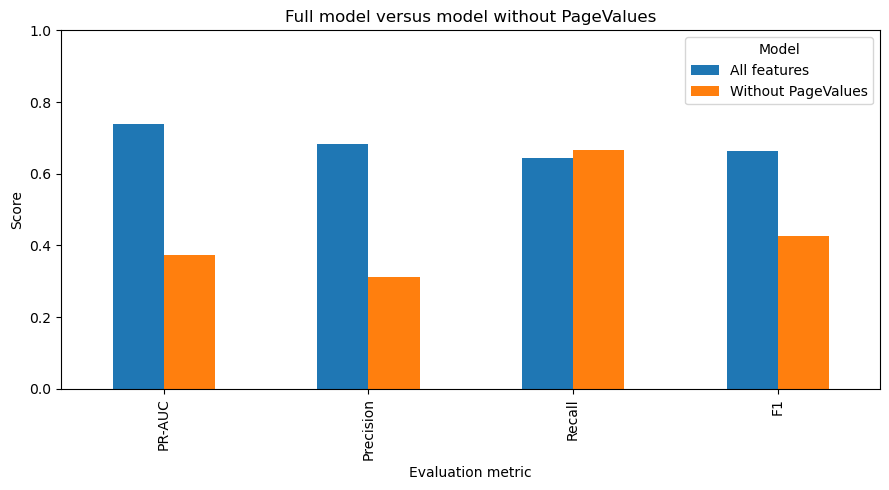

In [40]:
X_no_page_value = df.drop(columns=[target, "PageValues"])
y_sensitivity = y.copy()

numeric_no_page_value = [
    column for column in numeric_features if column != "PageValues"
]

preprocessor_no_page_value = ColumnTransformer(
    transformers=[
        ("numeric", clone(numeric_pipeline), numeric_no_page_value),
        ("categorical", clone(categorical_pipeline), categorical_features)
    ]
)

X_train_npv = X_no_page_value.loc[X_train.index]
X_validation_npv = X_no_page_value.loc[X_validation.index]
X_test_npv = X_no_page_value.loc[X_test.index]

sensitivity_model = Pipeline(steps=[
    ("preprocessor", preprocessor_no_page_value),
    ("model", clone(model_definitions[best_model_name]))
])

sensitivity_model.fit(X_train_npv, y_train)
validation_probability_npv = sensitivity_model.predict_proba(X_validation_npv)[:, 1]

p_npv, r_npv, t_npv = precision_recall_curve(
    y_validation, validation_probability_npv
)
thresholds_npv = pd.DataFrame({
    "threshold": t_npv,
    "precision": p_npv[:-1],
    "recall": r_npv[:-1]
})
thresholds_npv["f1"] = (
    2 * thresholds_npv["precision"] * thresholds_npv["recall"] /
    (thresholds_npv["precision"] + thresholds_npv["recall"])
).fillna(0)
selected_threshold_npv = float(
    thresholds_npv.loc[thresholds_npv["f1"].idxmax(), "threshold"]
)

sensitivity_model.fit(
    pd.concat([X_train_npv, X_validation_npv]),
    pd.concat([y_train, y_validation])
)
test_probability_npv = sensitivity_model.predict_proba(X_test_npv)[:, 1]

sensitivity_results = pd.DataFrame([
    metric_row(
        "All features",
        y_test,
        test_probability,
        selected_threshold
    ),
    metric_row(
        "Without PageValues",
        y_test,
        test_probability_npv,
        selected_threshold_npv
    )
])

display(sensitivity_results)

metrics_to_plot = ["PR-AUC", "Precision", "Recall", "F1"]
sensitivity_plot = sensitivity_results.set_index("Model")[metrics_to_plot].T

fig, ax = plt.subplots(figsize=(9, 5))
sensitivity_plot.plot(kind="bar", ax=ax)
ax.set_title("Full model versus model without PageValues")
ax.set_xlabel("Evaluation metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Model")
finish_figure(fig, "14_pagevalues_sensitivity.png")

**Sensitivity interpretation: the central business finding**

The performance gap between the full and no-`PageValues` models is not merely a technical footnote. It changes the product strategy.

| Model | Best use | Main strength | Main risk |
|---|---|---|---|
| **Full model** | Late-session ranking and operational prioritisation | Strong discrimination and lift | May rely on information too close to conversion |
| **No-`PageValues` model** | Earlier-session assistance experiments | More plausible feature timing | Lower predictive power and more false positives |

Therefore, the honest conclusion is not “the model predicts purchases with very high accuracy.” It is:

> Late-stage purchase intent is highly rankable in this dataset, but early intervention is materially harder. The organisation should deploy separate scores for separate decision moments and test whether any intervention generates incremental value.

A lower-performing early model may still be commercially useful if the action is cheap, non-intrusive and capacity-constrained. Conversely, a high-performing late model can destroy margin if it distributes incentives to customers who would have purchased anyway.

## Recommendations and limitations

**Recommended operating approach**

1. Maintain separate early and late-session scores rather than one universal model.
2. Use the early score for cheap, reversible assistance such as product guidance, delivery information or live-chat availability.
3. Use the richer late score for ranking and service prioritisation only after confirming feature timing.
4. Choose thresholds using capacity and expected value, not F1 alone.
5. Monitor conversion prevalence, PR-AUC, calibration, precision and recall by visitor type, month, weekend status and traffic source.
6. Run randomised experiments before claiming that any intervention creates incremental conversion or margin.

**Important limitations**

- The data contain no causal treatment assignment, customer identifier, transaction value, campaign cost or reliable event timeline.
- A random split may overstate performance under future seasonality or website change.
- Exact duplicates are ambiguous, and coded technical categories may drift.
- Strong predictive performance can still be commercially weak when it relies on outcome-adjacent information or targets customers who would purchase anyway.